# K-means clustering of OpenAQ air-quality measurements

### Jadibuti (SC-35)-GD Labs | Location 6133623

An exploratory analysis of hourly pollutant and weather profiles using feature engineering, scaler and cluster-count tuning, internal evaluation scores, and visual diagnostics.

## 1. Data source and study question

This notebook explores whether hourly observations from one air-quality monitor can be grouped into recurring measurement profiles using K-means. The source is the [OpenAQ Explorer location page](https://explore.openaq.org/locations/6133623#download-card); the supplied CSV was downloaded from that page.

**Study question:** Which measurement profiles recur across the observed hours, and how many clusters give the strongest internal separation under a transparent model-selection rule?

The result is exploratory: clusters are not official AQI categories, health-risk labels, or evidence of causes. This file covers one monitor and a finite date window. K-means favors roughly compact, spherical groups and can change with feature choices and scaling.

In [12]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")

candidate_paths = [
    Path.cwd() / "dataset" / "openaq_location_6133623_measurments.csv",
    Path.cwd().parent / "dataset" / "openaq_location_6133623_measurments.csv",
]
DATA_PATH = next((path for path in candidate_paths if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find dataset/openaq_location_6133623_measurments.csv. "
        "Run this notebook from the project root or its notebooks folder."
    )

raw = pd.read_csv(DATA_PATH)
raw["datetimeUtc"] = pd.to_datetime(raw["datetimeUtc"], utc=True, errors="coerce")
print(f"Loaded {len(raw):,} rows from {DATA_PATH}")
print(f"Columns: {raw.columns.tolist()}")
raw.head()

Loaded 5,000 rows from d:\Bivek Study Files\projects\kmeans-jadibutti-aqi-data\dataset\openaq_location_6133623_measurments.csv
Columns: ['location_id', 'location_name', 'parameter', 'value', 'unit', 'datetimeUtc', 'datetimeLocal', 'timezone', 'latitude', 'longitude', 'country_iso', 'isMobile', 'isMonitor', 'owner_name', 'provider']


,location_id,location_name,parameter,value,unit,datetimeUtc,datetimeLocal,timezone,latitude,longitude,country_iso,isMobile,isMonitor,owner_name,provider
0,6133623,Jadibuti (SC-35)-GD Labs,pm1,24.386000,µg/m³,2025-11-17 10:00:00+00:00,2025-11-17T15:45:00+05:45,Asia/Kathmandu,27.682109,85.354791,NaN,NaN,NaN,Green Decision Labs and Research,AirGradient
1,6133623,Jadibuti (SC-35)-GD Labs,pm1,21.281000,µg/m³,2025-11-17 11:00:00+00:00,2025-11-17T16:45:00+05:45,Asia/Kathmandu,27.682109,85.354791,NaN,NaN,NaN,Green Decision Labs and Research,AirGradient
2,6133623,Jadibuti (SC-35)-GD Labs,pm1,23.072167,µg/m³,2025-11-17 12:00:00+00:00,2025-11-17T17:45:00+05:45,Asia/Kathmandu,27.682109,85.354791,NaN,NaN,NaN,Green Decision Labs and Research,AirGradient
3,6133623,Jadibuti (SC-35)-GD Labs,pm1,24.239500,µg/m³,2025-11-17 13:00:00+00:00,2025-11-17T18:45:00+05:45,Asia/Kathmandu,27.682109,85.354791,NaN,NaN,NaN,Green Decision Labs and Research,AirGradient
4,6133623,Jadibuti (SC-35)-GD Labs,pm1,34.002833,µg/m³,2025-11-17 14:00:00+00:00,2025-11-17T19:45:00+05:45,Asia/Kathmandu,27.682109,85.354791,NaN,NaN,NaN,Green Decision Labs and Research,AirGradient


## 2. Data audit

The source file is in long format: each timestamp has one row per parameter. First verify the keys, coverage, missingness, and basic value ranges before reshaping.

In [13]:
print(f"Shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"UTC period: {raw['datetimeUtc'].min()} to {raw['datetimeUtc'].max()}")
source_missing = raw.isna().sum()
print(f"Missing cells across all source fields: {int(source_missing.sum()):,}")
print(f"Missing measurement values: {int(raw['value'].isna().sum()):,}")
print("Source fields with blanks:")
display(source_missing[source_missing.gt(0)].rename("missing_cells").to_frame())
print(f"Invalid timestamps: {int(raw['datetimeUtc'].isna().sum())}")
print(f"Duplicate timestamp/parameter keys: {int(raw.duplicated(['datetimeUtc', 'parameter']).sum())}")

quality_by_parameter = (
    raw.groupby("parameter", as_index=False)
    .agg(
        rows=("value", "size"),
        missing_values=("value", lambda values: values.isna().sum()),
        unique_timestamps=("datetimeUtc", "nunique"),
        minimum=("value", "min"),
        median=("value", "median"),
        maximum=("value", "max"),
    )
)
display(quality_by_parameter)
display(raw["parameter"].value_counts().rename("row_count").to_frame())

Shape: 5,000 rows x 15 columns
UTC period: 2025-11-17 10:00:00+00:00 to 2025-12-29 10:00:00+00:00
Missing cells across all source fields: 15,000
Missing measurement values: 0
Source fields with blanks:


,missing_cells
country_iso,5000
isMobile,5000
isMonitor,5000


Invalid timestamps: 0
Duplicate timestamp/parameter keys: 0


,parameter,rows,missing_values,unique_timestamps,minimum,median,maximum
0,pm1,1000,0,1000,2.325333,48.986000,142.338319
1,pm25,1000,0,1000,5.264000,77.023979,261.998164
2,relativehumidity,1000,0,1000,23.729333,43.603917,51.169167
3,temperature,1000,0,1000,14.946000,19.868750,30.910333
4,um003,1000,0,1000,365.022668,3599.192997,10498.268896


,row_count
parameter,
pm1,1000
pm25,1000
relativehumidity,1000
temperature,1000
um003,1000


## 3. Reshape and engineer features

K-means expects one numeric feature vector per observation. We pivot the five hourly measurements into one row per UTC timestamp, then add interpretable particle ratio and cyclical local-time features. Static monitor metadata is deliberately excluded because it cannot distinguish hours at one fixed location.

In [14]:
PARAMETERS = sorted(raw["parameter"].dropna().unique().tolist())
assert raw["datetimeUtc"].notna().all(), "Invalid UTC timestamp found."
assert not raw.duplicated(["datetimeUtc", "parameter"]).any(), "Duplicate measurement key found."

wide = raw.pivot(index="datetimeUtc", columns="parameter", values="value").sort_index()
wide.columns.name = None
local_times = (
    raw[["datetimeUtc", "datetimeLocal"]]
    .drop_duplicates("datetimeUtc")
    .set_index("datetimeUtc")
)
wide = wide.join(local_times)
for parameter in PARAMETERS:
    wide[parameter] = pd.to_numeric(wide[parameter], errors="coerce")

local_datetime = pd.to_datetime(wide["datetimeLocal"], errors="coerce")
wide["local_hour"] = local_datetime.dt.hour + local_datetime.dt.minute / 60
wide["local_weekday"] = local_datetime.dt.dayofweek
wide["pm25_to_pm1"] = wide["pm25"] / wide["pm1"].replace(0, np.nan)
wide["hour_sin"] = np.sin(2 * np.pi * wide["local_hour"] / 24)
wide["hour_cos"] = np.cos(2 * np.pi * wide["local_hour"] / 24)
wide["weekday_sin"] = np.sin(2 * np.pi * wide["local_weekday"] / 7)
wide["weekday_cos"] = np.cos(2 * np.pi * wide["local_weekday"] / 7)

feature_columns = PARAMETERS + [
    "pm25_to_pm1", "hour_sin", "hour_cos", "weekday_sin", "weekday_cos"
]
model_data = wide.dropna(subset=feature_columns).copy()
X = model_data[feature_columns].astype(float)
assert X.select_dtypes(include=np.number).shape[1] == len(feature_columns)
assert np.isfinite(X.to_numpy()).all(), "Feature matrix has non-finite values."

print(f"Pivoted observations: {len(wide):,} timestamps")
print(f"Engineered model features ({len(feature_columns)}): {feature_columns}")
print(f"Rows retained for modeling: {len(X):,}")
display(X.head())

Pivoted observations: 1,000 timestamps
Engineered model features (10): ['pm1', 'pm25', 'relativehumidity', 'temperature', 'um003', 'pm25_to_pm1', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos']
Rows retained for modeling: 1,000


,pm1,pm25,relativehumidity,temperature,um003,pm25_to_pm1,hour_sin,hour_cos,weekday_sin,weekday_cos
datetimeUtc,,,,,,,,,,
2025-11-17 10:00:00+00:00,24.386000,37.991833,35.963000,26.098333,1433.308333,1.557936,-0.831470,-0.555570,0.0,1.0
2025-11-17 11:00:00+00:00,21.281000,32.780500,36.886833,25.231500,1136.150507,1.540365,-0.946930,-0.321439,0.0,1.0
2025-11-17 12:00:00+00:00,23.072167,37.175000,40.102334,23.947000,1324.049495,1.611249,-0.997859,-0.065403,0.0,1.0
2025-11-17 13:00:00+00:00,24.239500,38.208500,42.739000,23.129667,1446.168994,1.576291,-0.980785,0.195090,0.0,1.0
2025-11-17 14:00:00+00:00,34.002833,52.447500,43.435833,22.648167,2459.722005,1.542445,-0.896873,0.442289,0.0,1.0


## 4. Exploratory visualizations

These views check coverage, distribution shape, extremes, temporal variation, and relationships before clustering. Concentration units follow the source file; `um003` is the monitor's reported particle-count channel, not a mass concentration.

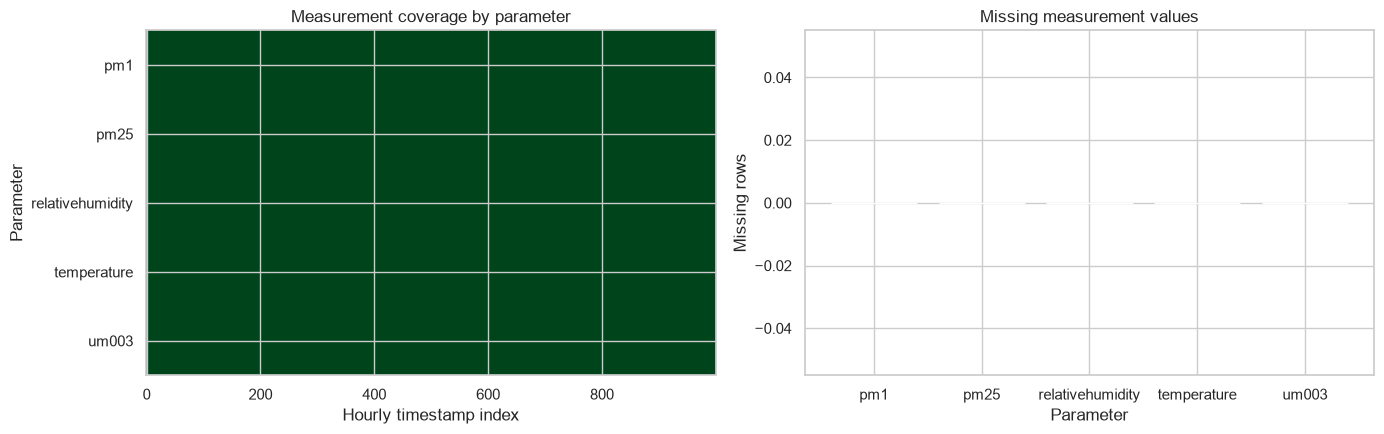

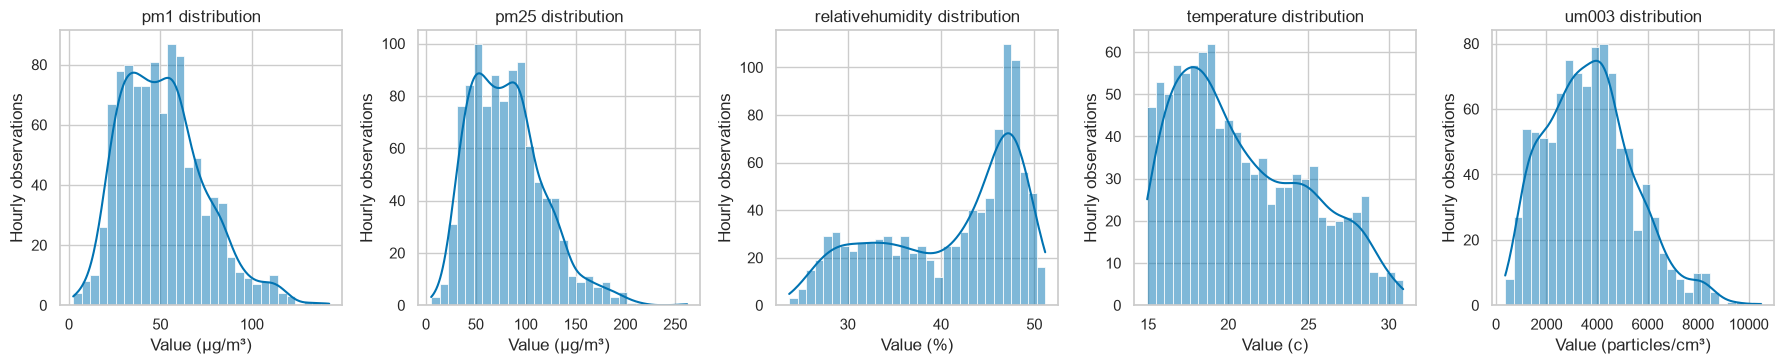

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
coverage = wide[PARAMETERS].notna().astype(int)
axes[0].imshow(coverage.T, aspect="auto", interpolation="nearest", cmap="Greens", vmin=0, vmax=1)
axes[0].set_yticks(range(len(PARAMETERS)), PARAMETERS)
axes[0].set_xlabel("Hourly timestamp index")
axes[0].set_title("Measurement coverage by parameter")
axes[0].set_ylabel("Parameter")
missing_measurements = raw.groupby("parameter")["value"].apply(lambda values: values.isna().sum())
axes[1].bar(missing_measurements.index, missing_measurements.values, color=sns.color_palette("colorblind", len(missing_measurements)))
axes[1].set_title("Missing measurement values")
axes[1].set_ylabel("Missing rows")
axes[1].set_xlabel("Parameter")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(PARAMETERS), figsize=(18, 3.8))
for axis, parameter in zip(axes, PARAMETERS):
    sns.histplot(raw.loc[raw["parameter"] == parameter, "value"], bins=30, kde=True, ax=axis, color=sns.color_palette("colorblind")[0])
    axis.set_title(f"{parameter} distribution")
    axis.set_xlabel(f"Value ({raw.loc[raw['parameter'] == parameter, 'unit'].dropna().iloc[0] if raw.loc[raw['parameter'] == parameter, 'unit'].notna().any() else 'source units'})")
    axis.set_ylabel("Hourly observations")
plt.tight_layout()
plt.show()

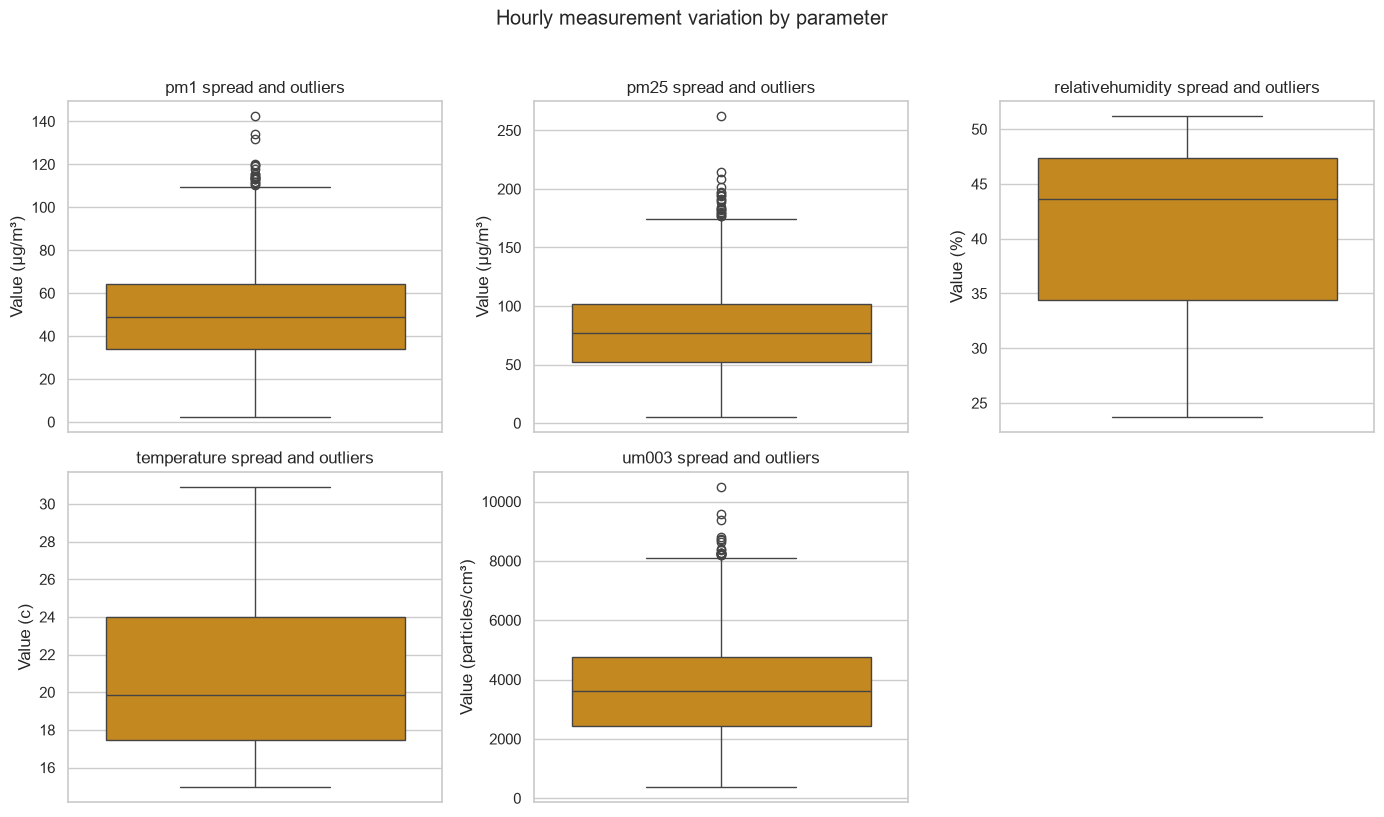

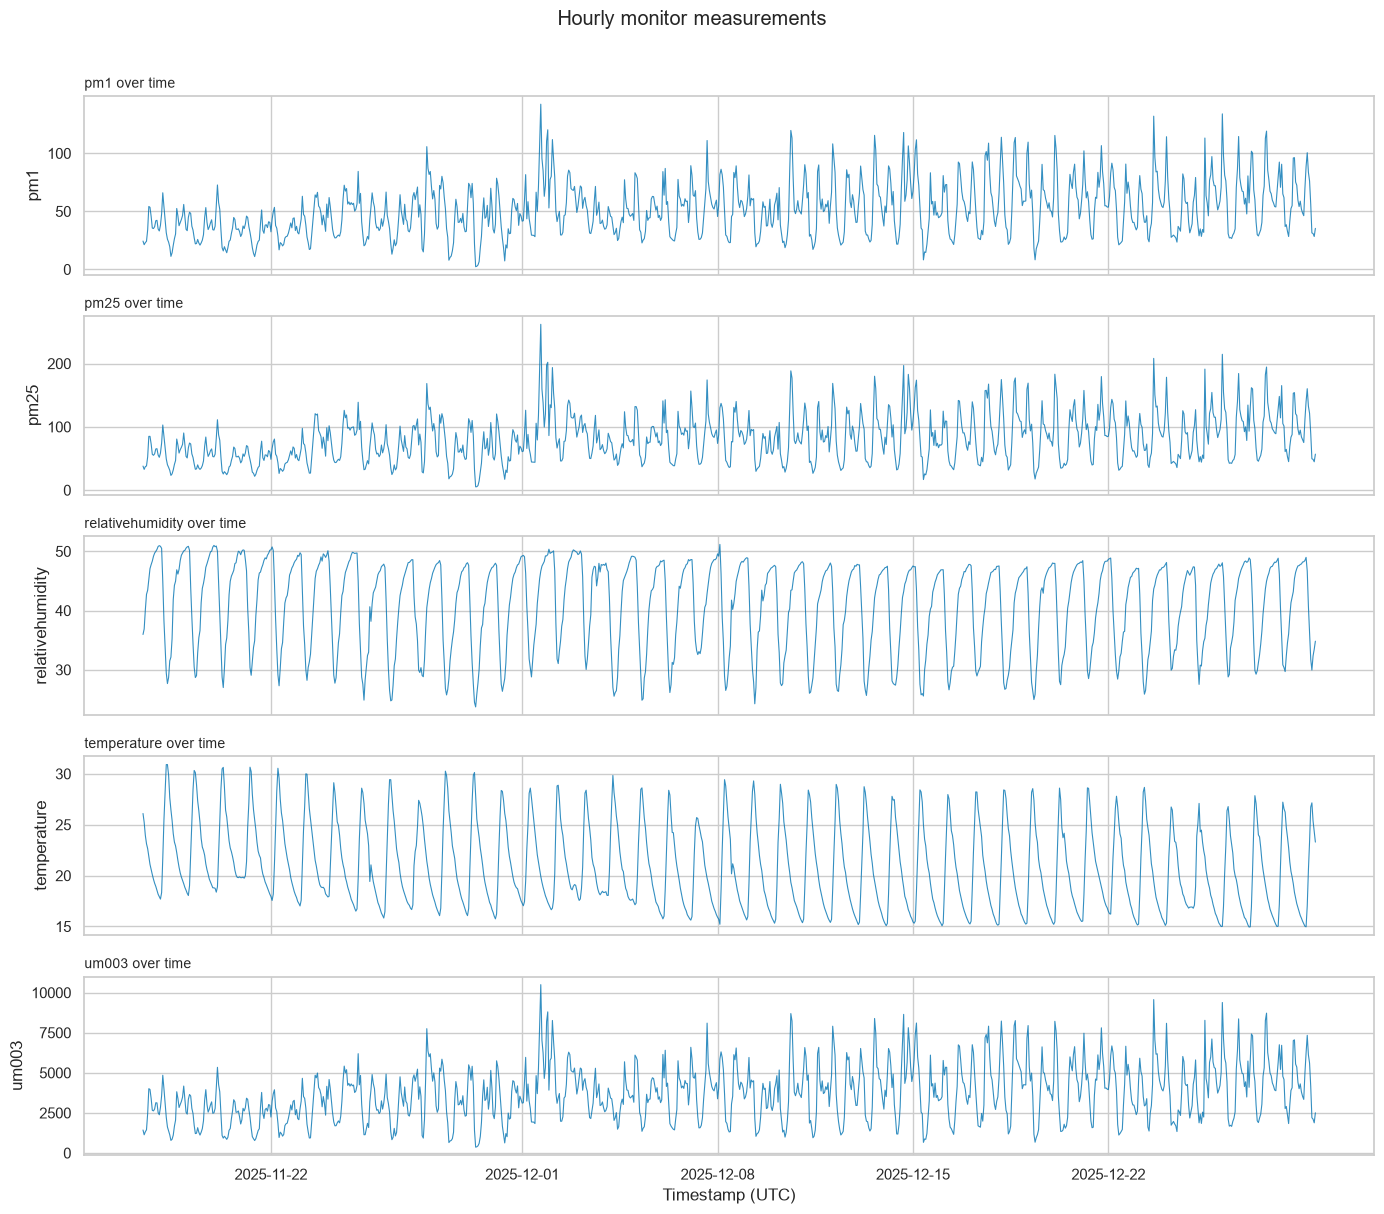

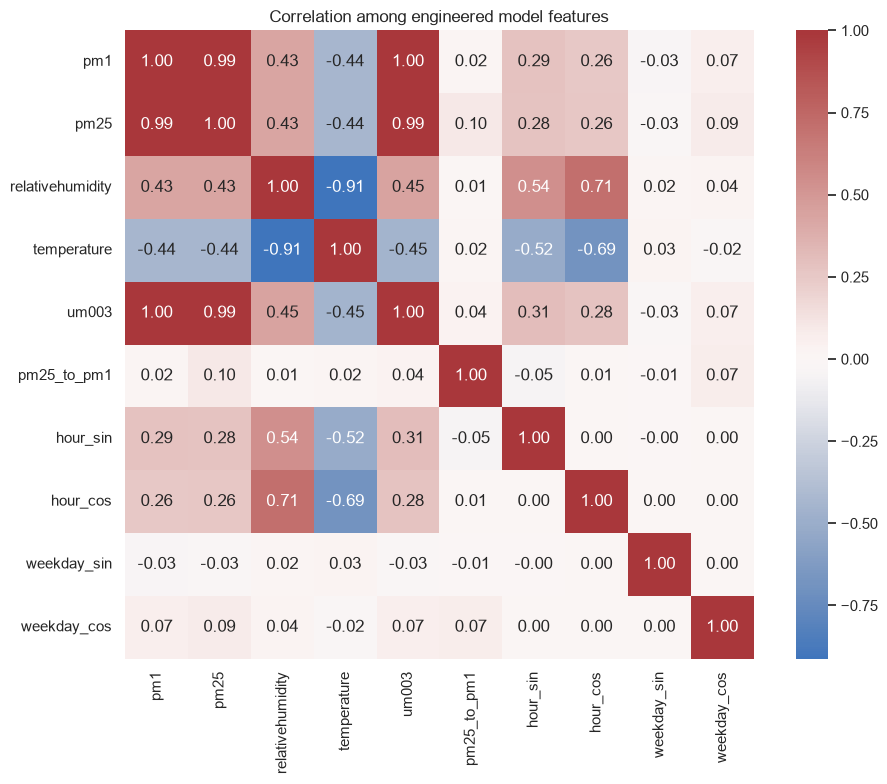

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for axis, parameter in zip(axes.flat, PARAMETERS):
    values = raw.loc[raw["parameter"] == parameter, "value"]
    sns.boxplot(y=values, ax=axis, color=sns.color_palette("colorblind")[1], showfliers=True)
    unit = raw.loc[raw["parameter"] == parameter, "unit"].dropna()
    axis.set_title(f"{parameter} spread and outliers")
    axis.set_ylabel(f"Value ({unit.iloc[0] if not unit.empty else 'source units'})")
axes.flat[-1].set_visible(False)
fig.suptitle("Hourly measurement variation by parameter", y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(PARAMETERS), 1, figsize=(14, 12), sharex=True)
for axis, parameter in zip(axes, PARAMETERS):
    axis.plot(wide.index, wide[parameter], linewidth=0.8, alpha=0.8)
    axis.set_ylabel(parameter)
    axis.set_title(f"{parameter} over time", loc="left", fontsize=10)
axes[-1].set_xlabel("Timestamp (UTC)")
fig.suptitle("Hourly monitor measurements", y=1.01)
plt.tight_layout()
plt.show()

correlation_features = X.corr()
fig, axis = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_features, cmap="vlag", center=0, annot=True, fmt=".2f", square=True, ax=axis)
axis.set_title("Correlation among engineered model features")
plt.tight_layout()
plt.show()

## 5. Tune scaling and number of clusters

We test `k = 2..10` with both standard and robust scaling. For each configuration, we record inertia, silhouette (primary selection score; higher is better), Davies–Bouldin (lower is better), and Calinski–Harabasz (higher is better). The selected configuration is the highest silhouette result; this is a reproducible internal criterion, not proof of a true number of natural groups. `n_init=20` and a fixed seed reduce sensitivity to K-means initialization.

In [17]:
scalers = {"StandardScaler": StandardScaler, "RobustScaler": RobustScaler}
tuning_rows = []
for scaler_name, scaler_class in scalers.items():
    for k in range(2, 11):
        candidate = Pipeline([
            ("scaler", scaler_class()),
            ("kmeans", KMeans(n_clusters=k, init="k-means++", n_init=20, random_state=RANDOM_STATE)),
        ])
        labels = candidate.fit_predict(X)
        scaled_X = candidate.named_steps["scaler"].transform(X)
        tuning_rows.append({
            "scaler": scaler_name,
            "k": k,
            "silhouette": silhouette_score(scaled_X, labels),
            "davies_bouldin": davies_bouldin_score(scaled_X, labels),
            "calinski_harabasz": calinski_harabasz_score(scaled_X, labels),
            "inertia": candidate.named_steps["kmeans"].inertia_,
        })

tuning_results = pd.DataFrame(tuning_rows).sort_values(
    ["silhouette", "davies_bouldin"], ascending=[False, True]
).reset_index(drop=True)
best_result = tuning_results.iloc[0]
best_scaler_name = best_result["scaler"]
best_k = int(best_result["k"])
print(f"Selected configuration: {best_scaler_name}, k={best_k}")
display(tuning_results.round(4))

Selected configuration: RobustScaler, k=2


,scaler,k,silhouette,davies_bouldin,calinski_harabasz,inertia
0,RobustScaler,2,0.3050,1.3077,422.2576,3171.6007
1,StandardScaler,2,0.3049,1.3234,476.7036,6767.4618
2,RobustScaler,4,0.2769,1.1637,399.5821,2048.2836
3,RobustScaler,5,0.2584,1.2460,371.8567,1809.0964
4,RobustScaler,6,0.2577,1.2296,355.4400,1618.9505
5,RobustScaler,3,0.2546,1.4126,367.0384,2599.5242
6,StandardScaler,3,0.2493,1.5517,375.5457,5703.3628
7,RobustScaler,7,0.2292,1.3129,330.3505,1506.4764
8,StandardScaler,4,0.2288,1.5394,305.3700,5208.9053
9,StandardScaler,6,0.2158,1.3596,262.6651,4308.0177


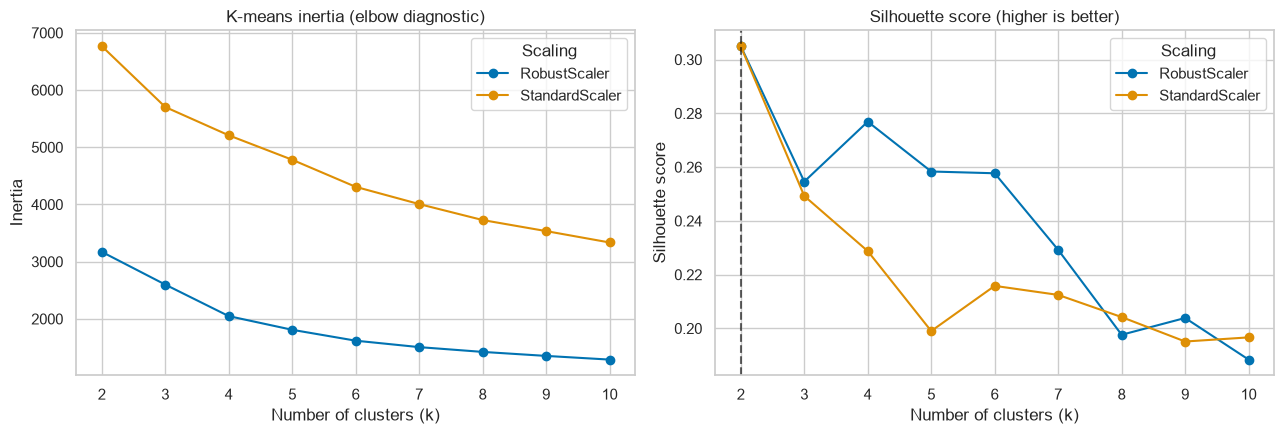

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for scaler_name, group in tuning_results.groupby("scaler"):
    group = group.sort_values("k")
    axes[0].plot(group["k"], group["inertia"], marker="o", label=scaler_name)
    axes[1].plot(group["k"], group["silhouette"], marker="o", label=scaler_name)
axes[0].set(title="K-means inertia (elbow diagnostic)", xlabel="Number of clusters (k)", ylabel="Inertia")
axes[1].set(title="Silhouette score (higher is better)", xlabel="Number of clusters (k)", ylabel="Silhouette score")
for axis in axes:
    axis.set_xticks(range(2, 11))
    axis.legend(title="Scaling")
axes[1].axvline(best_k, color="black", linestyle="--", alpha=0.6, label=f"Selected k={best_k}")
plt.tight_layout()
plt.show()

## 6. Final model and interpretation

Fit the selected pipeline once on the complete feature matrix. Internal metrics describe separation in this fitted data only; compare them with the tuning table and use domain knowledge before assigning descriptive names to clusters.

In [19]:
selected_scaler = scalers[best_scaler_name]()
final_model = Pipeline([
    ("scaler", selected_scaler),
    ("kmeans", KMeans(n_clusters=best_k, init="k-means++", n_init=20, random_state=RANDOM_STATE)),
])
final_labels = final_model.fit_predict(X)
final_scaled_X = final_model.named_steps["scaler"].transform(X)
clustered = model_data.copy()
clustered["cluster"] = final_labels
cluster_sizes = clustered["cluster"].value_counts().sort_index().rename("observations").to_frame()
cluster_profiles = clustered.groupby("cluster")[PARAMETERS + ["pm25_to_pm1"]].mean()

final_metrics = pd.DataFrame([{
    "scaler": best_scaler_name,
    "k": best_k,
    "silhouette": silhouette_score(final_scaled_X, final_labels),
    "davies_bouldin": davies_bouldin_score(final_scaled_X, final_labels),
    "calinski_harabasz": calinski_harabasz_score(final_scaled_X, final_labels),
    "inertia": final_model.named_steps["kmeans"].inertia_,
    "observations": len(X),
    "features": len(feature_columns),
}])
print("Final internal evaluation scores")
display(final_metrics.round(4))
print("Cluster sizes")
display(cluster_sizes)
print("Mean cluster profiles in original measurement units")
display(cluster_profiles.round(2))

Final internal evaluation scores


,scaler,k,silhouette,davies_bouldin,calinski_harabasz,inertia,observations,features
0,RobustScaler,2,0.305,1.3077,422.2576,3171.6007,1000,10


Cluster sizes


,observations
cluster,
0,356
1,644


Mean cluster profiles in original measurement units


,pm1,pm25,relativehumidity,temperature,um003,pm25_to_pm1
cluster,,,,,,
0,31.47,49.09,32.96,25.11,2148.82,1.57
1,62.46,98.75,45.36,18.48,4588.17,1.58


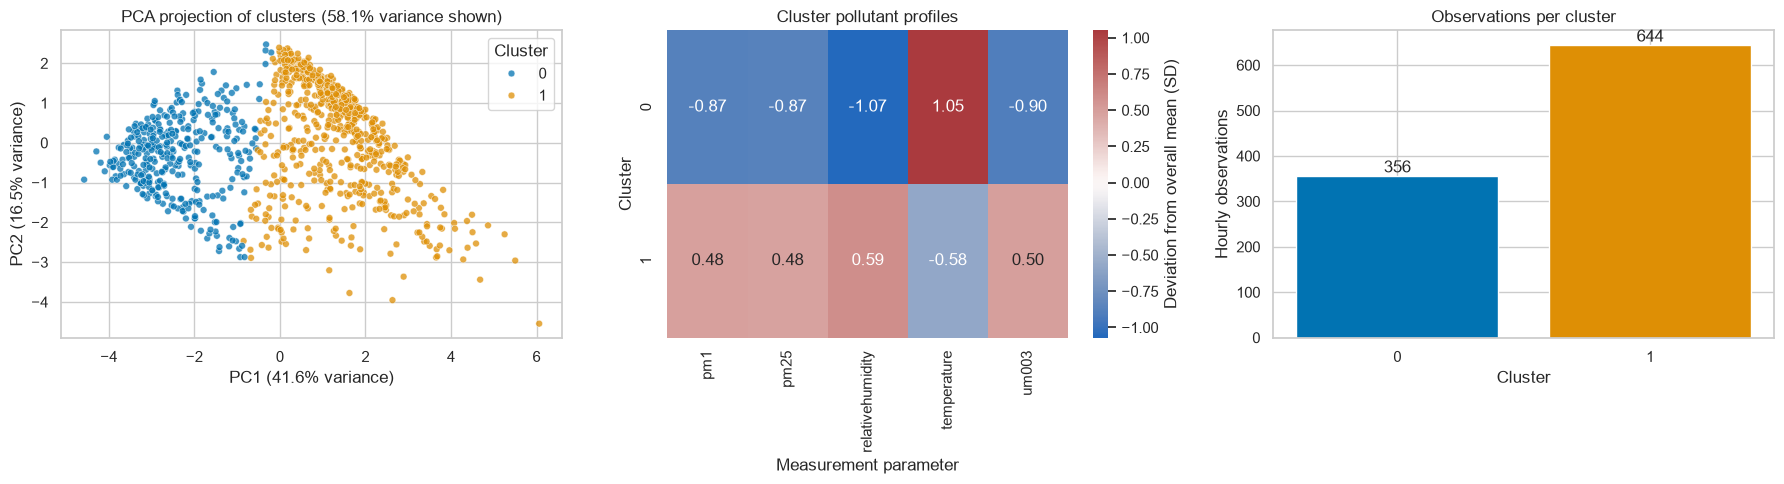

PCA is a 2-D visualization only; the model was fit in the full engineered feature space.


In [20]:
pca_scaler = StandardScaler()
pca_input = pca_scaler.fit_transform(X)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coordinates = pca.fit_transform(pca_input)
pca_variance = pca.explained_variance_ratio_
pca_view = pd.DataFrame({"PC1": pca_coordinates[:, 0], "PC2": pca_coordinates[:, 1], "cluster": final_labels.astype(str)})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=pca_view, x="PC1", y="PC2", hue="cluster", palette="colorblind", s=24, alpha=0.75, ax=axes[0])
axes[0].set_title(f"PCA projection of clusters ({pca_variance.sum():.1%} variance shown)")
axes[0].set_xlabel(f"PC1 ({pca_variance[0]:.1%} variance)")
axes[0].set_ylabel(f"PC2 ({pca_variance[1]:.1%} variance)")
axes[0].legend(title="Cluster")

profile_z = (cluster_profiles[PARAMETERS] - X[PARAMETERS].mean()) / X[PARAMETERS].std(ddof=0).replace(0, np.nan)
sns.heatmap(profile_z, cmap="vlag", center=0, annot=True, fmt=".2f", ax=axes[1], cbar_kws={"label": "Deviation from overall mean (SD)"})
axes[1].set_title("Cluster pollutant profiles")
axes[1].set_xlabel("Measurement parameter")
axes[1].set_ylabel("Cluster")

axes[2].bar(cluster_sizes.index.astype(str), cluster_sizes["observations"], color=sns.color_palette("colorblind", len(cluster_sizes)))
axes[2].set_title("Observations per cluster")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("Hourly observations")
for bar in axes[2].patches:
    axes[2].annotate(f"{int(bar.get_height())}", (bar.get_x() + bar.get_width() / 2, bar.get_height()), ha="center", va="bottom")
plt.tight_layout()
plt.show()
print("PCA is a 2-D visualization only; the model was fit in the full engineered feature space.")

In [21]:
profile_spread = cluster_profiles[PARAMETERS].max() - cluster_profiles[PARAMETERS].min()
most_separating_parameter = profile_spread.idxmax()
most_separating_unit = raw.loc[raw["parameter"] == most_separating_parameter, "unit"].dropna()
unit_label = most_separating_unit.iloc[0] if not most_separating_unit.empty else "source units"
profile_deviations = (cluster_profiles[PARAMETERS] - X[PARAMETERS].mean()) / X[PARAMETERS].std(ddof=0).replace(0, np.nan)

finding_lines = [
    f"Selected {best_scaler_name} with k={best_k}, chosen by the highest silhouette among 18 tested scaler/k combinations.",
    f"Final silhouette={final_metrics.loc[0, 'silhouette']:.3f}; Davies-Bouldin={final_metrics.loc[0, 'davies_bouldin']:.3f}; Calinski-Harabasz={final_metrics.loc[0, 'calinski_harabasz']:.1f}.",
    f"Cluster sizes range from {cluster_sizes['observations'].min():,} to {cluster_sizes['observations'].max():,} hourly observations.",
    f"The largest range between cluster-average pollutant levels is for {most_separating_parameter}: {profile_spread[most_separating_parameter]:.2f} {unit_label}.",
]
for cluster_id, deviations in profile_deviations.iterrows():
    strongest_feature = deviations.abs().idxmax()
    direction = "above" if deviations[strongest_feature] >= 0 else "below"
    mean_value = cluster_profiles.loc[cluster_id, strongest_feature]
    finding_lines.append(
        f"Cluster {cluster_id}: strongest pollutant contrast is {strongest_feature} "
        f"({mean_value:.2f} in source units, {abs(deviations[strongest_feature]):.2f} SD {direction} the overall mean)."
    )

findings_text = "\n".join(f"- {line}" for line in finding_lines)
print("DATA-DERIVED FINDINGS\n" + findings_text)
print("\nInterpretation: these are relative measurement profiles, not official AQI labels or health categories.")

PROJECT_ROOT = DATA_PATH.resolve().parent.parent
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
clustered.index.name = "datetimeUtc"
clustered.reset_index().to_csv(OUTPUT_DIR / "timestamp_clusters.csv", index=False)
tuning_results.to_csv(OUTPUT_DIR / "kmeans_tuning_metrics.csv", index=False)
cluster_profiles.reset_index().to_csv(OUTPUT_DIR / "cluster_profiles.csv", index=False)
final_metrics.to_csv(OUTPUT_DIR / "final_model_scores.csv", index=False)
(OUTPUT_DIR / "cluster_analysis_findings.txt").write_text(findings_text + "\n", encoding="utf-8")
print(f"\nSaved results to: {OUTPUT_DIR}")
print("  timestamp_clusters.csv, kmeans_tuning_metrics.csv, cluster_profiles.csv,")
print("  final_model_scores.csv, cluster_analysis_findings.txt")

DATA-DERIVED FINDINGS
- Selected RobustScaler with k=2, chosen by the highest silhouette among 18 tested scaler/k combinations.
- Final silhouette=0.305; Davies-Bouldin=1.308; Calinski-Harabasz=422.3.
- Cluster sizes range from 356 to 644 hourly observations.
- The largest range between cluster-average pollutant levels is for um003: 2439.35 particles/cm³.
- Cluster 0: strongest pollutant contrast is relativehumidity (32.96 in source units, 1.07 SD below the overall mean).
- Cluster 1: strongest pollutant contrast is relativehumidity (45.36 in source units, 0.59 SD above the overall mean).

Interpretation: these are relative measurement profiles, not official AQI labels or health categories.

Saved results to: D:\Bivek Study Files\projects\kmeans-jadibutti-aqi-data\outputs
  timestamp_clusters.csv, kmeans_tuning_metrics.csv, cluster_profiles.csv,
  final_model_scores.csv, cluster_analysis_findings.txt


## 7. Reproducibility and limitations

Run every cell from top to bottom. The fixed random seed is `42`; the model uses k-means++ initialization with 20 restarts. The search covers two scaling methods and k values 2 through 10, so its selected k is only the best among those tested. For a stronger follow-up, compare other feature sets, repeat the analysis over another season or monitoring site, and check whether profiles remain stable. Do not interpret the groups as regulatory AQI bands or causal effects.

The notebook writes the timestamp-level assignments, tuning table, cluster profiles, final scores, and generated findings under `outputs/`.